# Team Member 3 Review -- Analysis of Python Quiz Responses

## Introduction and Aim

In this project, I, as part of a team, analysed a large dataset consisting of answers to a quiz.

The quiz consisted of 100 multiple-choice questions each with four numerically marked options for answers (1, 2, 3 and 4).

Respondents' selected answers were indicated by [X] and non-answers by [] (empty brackets).

The aim of this project was to investigate:

> Is there any deliberate pattern in the correct answer sequence set?

##The Pipeline
For the project, the group worked collaboratively via GitHub. Each team member was responsible for implementing a module involving certain functions in order to properly process, collate and analyse the dataset.

The data extraction module began the process with each respondent's selected answers being extracted from their completed quiz file (which includes questions) to store their selected answers as 100-value sequence in a unique file.

Using the data preparation module, each respondent's answer file is then downloaded and saved in the repository, before all these files are collated into a single unified file to be processed.

As team member 3, I was responsible for the analysis module. This module extracted the answer sequences from the unified file to compute statistics required to visualise the data in a way that would allows us to detect and patterns in the data in order to draw conclusions.

The final module integrated the extraction, preparation and analysis processes to execute the complete analysis pipeline to investigate the quiz setter's pattern.

I have summarised the process below:

- data_extraction_M1: Data is parsed into structured sequences
↓

- data_preparation_M2: Respondent answer files combined into unified file
↓

- **data_analysis_M3: Statistics are computed to produce visualisations**
↓

- run_full_analysis_M4: All modules integrated to complete analysis pipeline.

##My Contribution

To implement my data analysis module, I designed 3 functions:
- **load_sequences** to import the data as individual respondent records;
- **generate_means_sequence** to process the answer sequences and calculate the mean of all the respondents' answers to each question, and
- **visualize_data** to produce visualisations of the data to gain insights and identify potential patterns in the data.

### load_sequences

In [7]:
import matplotlib.pyplot as plt

def load_sequences(collated_answers_path):
  with open(collated_answers_path, "r") as f:
    blocks = f.read().strip().split("\n*\n")

  sequences = []

  for block in blocks:
      lines = block.splitlines()
      answers = []

      i = 0
      while i < len(lines):
          if lines[i].startswith("Question"):
              for j in range(4):
                  if "[X]" in lines[i + j + 1]:
                      answers.append(j + 1)
                      break
                  else:
                    answers.append(0)

                  i += 5
          else:
              i += 1

          if len(answers) == 100:
            sequences.append(answers)

  return sequences

This is a helper function that reads the collated_answers.txt file in which all the respondents' answers are collated. This was necessary as I could not access the extract_answers_sequence function from the data extraction module.

Using a count-controlled loop, the function iterates through the file to split each respondent's answers into a unique block.

Hence, for each respondent, a structured numerical sequence of 100 values is created, indicating the sequence of answers the respondent selected (with 0 representing non-answer).

This converts the collated data into a purely numerical format which allows for the means of the answers to be computed efficiently with the generate_means_sequence function.

### generate_means_sequence

In [8]:
def generate_means_sequence(collated_answers_path):
  sequences = load_sequences(collated_answers_path)

  means = []

  for q in range(len(sequences[0])):

      values = []

      for student in sequences:
          val = student[q]
          if val != 0:
              values.append(val)

      if len(values) == 0:
          means.append(0)
      else:
          means.append(sum(values) / len(values))

  return means

This function computes the main analytical output: the mean of all the mean of all the respondents answers for each of the 100 questions in this quiz.

To do this, it takes the structured answer sequences for each student from the load_sequences function and sequentially iterates through to aggregate the reponses across all respondents to the same question and compute the mean answer.

Unanswered questions which are coded as zero, are discounted when calculating the mean per question.

The function outputs a sequence of 100 values which gives the trend of average responses across the quiz. This data is used to detect any patterns in the overall sequence of answers from the whole cohort. This data is represented visually using the visualize_data function.

### visualize_data

In [9]:
def visualize_data(collated_answers_path, n):
  sequences = load_sequences(collated_answers_path)

  if n == 1:
      means = generate_means_sequence(collated_answers_path)

      plt.scatter(range(len(means)), means)
      plt.title("Mean Answer Per Question")
      plt.xlabel("Question")
      plt.ylabel("Mean Answer")

      plt.savefig("output/means_scatter_graph.png")
      plt.clf()

  elif n == 2:
      for seq in sequences:
          plt.plot(range(len(seq)), seq, alpha=0.3)

      plt.title("All Respondent Answer Sequences")
      plt.xlabel("Question")
      plt.ylabel("Answer")

      plt.savefig("output/all_sequences_line_graph.png")
      plt.clf()

  else:
      print("Error: n must be 1 or 2")
      return

This function translates the computed statistics into two different types of visualisations so patterns in the data can be identified and compared.

The function takes the dataset as an input, alongide an integer 1 or 2 which indicates the desired plot.

When n = 1, the function plots a scatter graph of the sequence of mean answers across the quiz, which shows the overall trends or structure across the whole cohort.

When n = 2, the function plots a line graph showing the individual answer sequences for each of the respondents. This can show any patterns or structure in the way each respondent independently chose to select their answers on the quiz, so respondent behaviour can be compared.

## Insights from Visualisations and Integration Report
Using the visualize_data function, the line and scatter plots were saved to the /output folder in the repository as png image files.
Below, I discuss the insights gained from the graphs and supporting evidence from the statistics within the Team Member 4 Integration Report, located in the output folder in the repository.

### Scatter Graph of Mean Answer Per Question

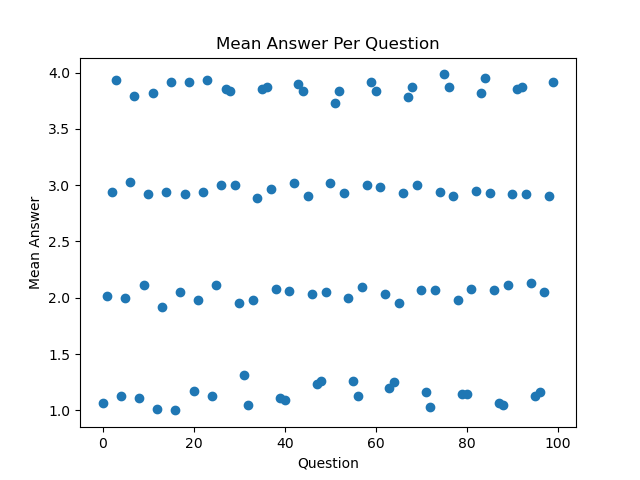

#### Interpretation
The scatter graph of the mean answers per question shows four consistent horizontal bands around the answers 1.0, 2.0, 3.0 and 4.0.

This indicates that the mean of the respondents' answers per question tends to cluster around discrete integer values rather than spreading across decimal ranges.

This suggests that the repondents tended to select the same answers for each individual question.

The notion of consensus amongst the respondents suggested by the scatter graph is supported by the statistics in the Team Member 4 Integration Report found in the output folder of the GitHub repository.

Here the first 20 rounded mean answer values are listed numerically:

> 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4

showing that for the sample of the first 20 questions in the quiz, respondents typically gave the same answer to each question.

However, it is not entirely clear from the graph that there is a pattern to how the answers are ordered across the quiz, since the clustering shown on the graoh does not clearly indicate how the answers are sequenced from question to question.

In addition, the integration report indicates that when the mean answers are rounded to the nearest integer, the distribution of answers is spread evenly: each answer of 1, 2, 3, 4 is the mean answer for 25 questions in the quiz.

This suggests that overall, there was no strong bias to a certain answer across the questions. However, as the data is rounded, this cannot be taken as absolutely reflective of the exact answers chosen.

### Line Graph of All Respondent Answer Sequences
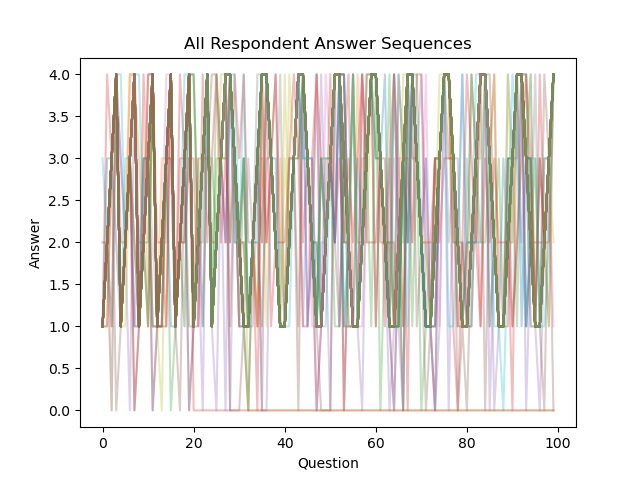

#### Interpretation
The line graph of individual respondent's answer sequences shows that the vast majority of the respondents' answers between 1.0 and 4.0 across the quiz.

In this range on the graph, there is dense overlap as several lines follow the same oscillation, a sharp zigzagging between 1 and 4 across the hundred questions.

This indicates that individual respondent's answers followed a consistent pattern throughout the quiz, possibly indicating a strategy.

This also suggests some consistency between respondents as the overlap and similar oscillation indicates that the sequences of some respondents' answers showed the same pattern across the quiz.

This insight is supported by the integration report since the first 20 rounded mean answer values:

> 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4

form a repeating 1-2-3-4 pattern and the periodicity check in the report indicates that the best candidate period is 4.

However, the graph also shows reaching the 0 answer point for several different questions, showing that respondents did not answer some questions on the quiz, and the exact questions they did not answer varied.

For example, the long orange line along the 0 answer shows that only one respondent didn't answer approximately the last 80 questions of the quiz.

This is supported by the integration report, which states that the number of mismatches as 36, suggesting that the periodic nature of respondents' answer sequences is not absolute as there is some variability. Hence, any possible pattern is not strictly observed in a global manner across all the respondents.

## Conclusions
Overall, considering the results shown in the data visualisations and the integration report, I can conclude that although there is some evidence to indicate consistency across the cohort's answers, there is also evidence to suggest that any potential patterns are more significant at an individual level than across all respondents.

Therefore, there is not definitive evidence of a deliberate pattern in the correct answer sequence.